# 03 — Feature Engineering

Build all ML features from the cleaned data, check their distributions and correlation with the target, then save the feature matrix.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

def find_project_root(start, depth=5):
    path = start.resolve()
    for _ in range(depth):
        if (path / "src").exists() and (path / "requirements.txt").exists():
            return path
        path = path.parent
    raise RuntimeError(f"Can't find project root from {start}")

PROJECT_ROOT  = find_project_root(Path.cwd())
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR   = PROJECT_ROOT / "outputs" / "figures"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT))
from src.data_loader import load_raw_tables, build_master_df, add_parsed_lap_times
from src.features import build_feature_set, FEATURE_COLUMNS, TARGET_COLUMN

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 50)
print("Root:", PROJECT_ROOT)

Root: C:\Users\Agam Katiyar\Projects\f1-ml-predictions


## Load cleaned data

In [2]:
df = pd.read_csv(PROCESSED_DIR / "master_cleaned.csv")
print(df.shape)
df.head(3)

(26759, 29)


,resultId,raceId,driverId,constructorId,grid,position,positionText,positionOrder,points,laps,rank,statusId,year,round,circuitId,name,driverRef,nationality_driver,dob,constructorRef,nationality_constructor,points_driver_standing,position_driver_standing,wins,points_constructor_standing,position_constructor_standing,q1_seconds,q2_seconds,q3_seconds
0,1,18,1,1,1,1.0,1,1,10.0,58,2.0,1,2008,1,1,Australian Grand Prix,hamilton,British,1985-01-07,mclaren,British,10.0,1.0,1.0,14.0,1.0,86.572,85.187,86.714
1,2,18,2,2,5,2.0,2,2,8.0,58,3.0,1,2008,1,1,Australian Grand Prix,heidfeld,German,1977-05-10,bmw_sauber,German,8.0,2.0,0.0,8.0,3.0,85.960,85.518,87.236
2,3,18,3,3,7,3.0,3,3,6.0,58,5.0,1,2008,1,1,Australian Grand Prix,rosberg,German,1985-06-27,williams,British,6.0,3.0,0.0,9.0,2.0,86.295,86.059,88.687


## Build features

All the logic lives in `src/features.py`. Calling `build_feature_set()` adds every engineered column in the right order.

In [3]:
df_feat = build_feature_set(df)
print("New columns added:")
new_cols = [c for c in df_feat.columns if c not in df.columns]
print(new_cols)
df_feat[FEATURE_COLUMNS + [TARGET_COLUMN]].head(10)

New columns added:
['is_podium', 'grid_position', 'driver_avg_finish_last5', 'constructor_avg_finish_last5', 'driver_career_podium_rate', 'q3_gap_to_pole', 'points_gap_to_leader']


,grid_position,q3_seconds,q3_gap_to_pole,q1_seconds,driver_avg_finish_last5,constructor_avg_finish_last5,driver_career_podium_rate,points_gap_to_leader,is_podium
0,1,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1
1,2,NaN,NaN,NaN,NaN,1.0,NaN,3.0,1
2,4,NaN,NaN,NaN,NaN,1.0,NaN,5.0,1
3,6,NaN,NaN,NaN,NaN,NaN,NaN,6.0,0
4,9,NaN,NaN,NaN,NaN,4.0,NaN,7.0,0
5,13,NaN,NaN,NaN,NaN,NaN,NaN,9.0,0
6,15,NaN,NaN,NaN,NaN,6.0,NaN,9.0,0
7,14,NaN,NaN,NaN,NaN,4.0,NaN,9.0,0
8,16,NaN,NaN,NaN,NaN,NaN,NaN,9.0,0
9,20,NaN,NaN,NaN,NaN,9.0,NaN,9.0,0


## NaN check on feature columns

Some NaNs are expected — e.g. a driver's first race has no rolling form yet.

In [4]:
feat_nulls = df_feat[FEATURE_COLUMNS].isnull().sum()
feat_pct   = (feat_nulls / len(df_feat) * 100).round(1)
pd.DataFrame({"nulls": feat_nulls, "pct%": feat_pct})

,nulls,pct%
grid_position,0,0.0
q3_seconds,23130,86.4
q3_gap_to_pole,23130,86.4
q1_seconds,16421,61.4
driver_avg_finish_last5,861,3.2
constructor_avg_finish_last5,211,0.8
driver_career_podium_rate,861,3.2
points_gap_to_leader,469,1.8


## Feature distributions

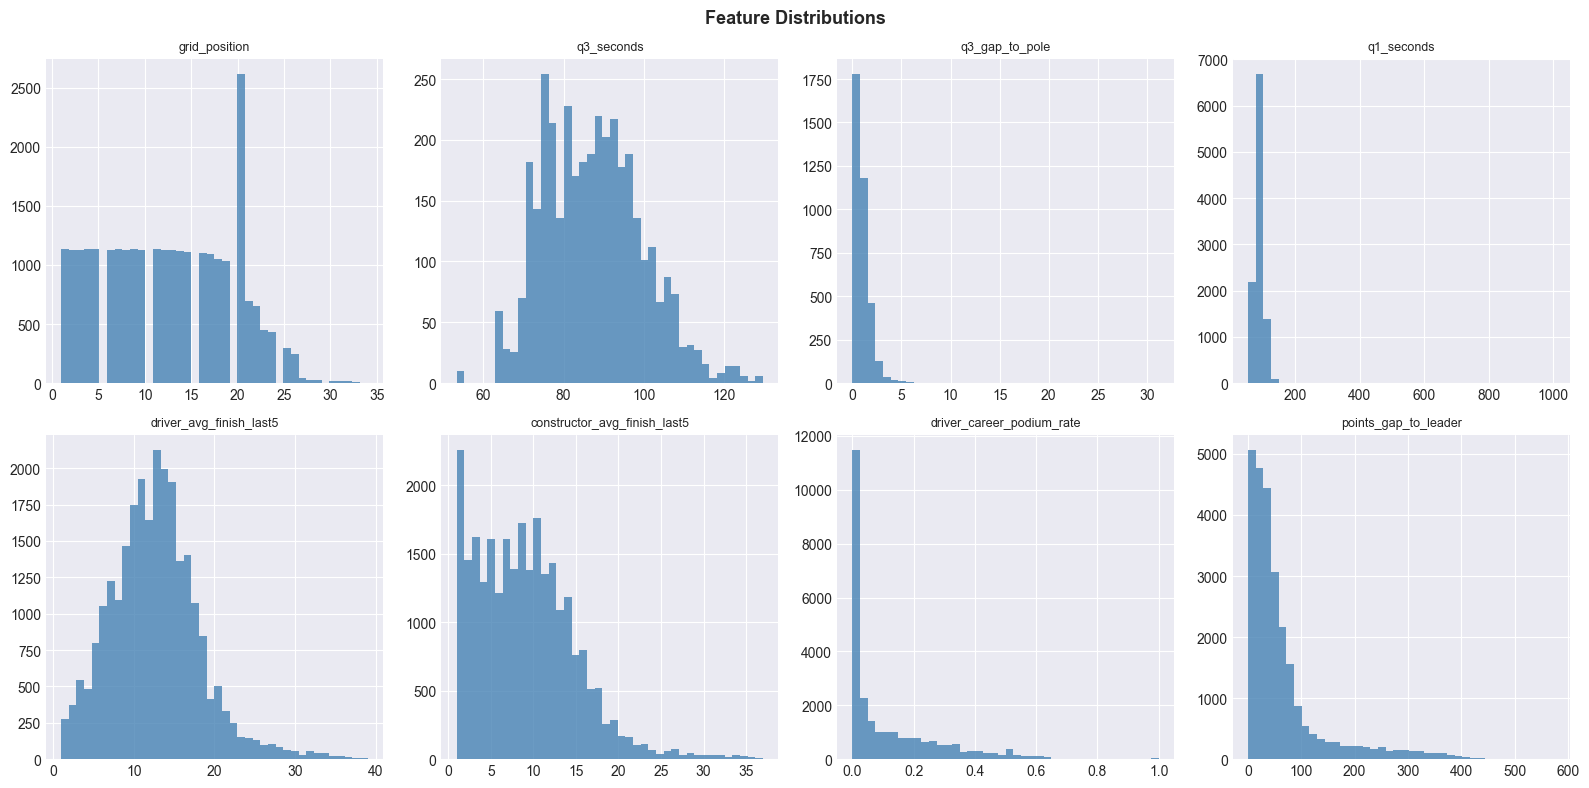

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLUMNS):
    data = df_feat[col].dropna()
    axes[i].hist(data, bins=40, color="steelblue", edgecolor="none", alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

plt.suptitle("Feature Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_distributions.png", dpi=150)
plt.show()

## Correlation with target

Simple point-biserial correlation — how linearly related each feature is to `is_podium`.

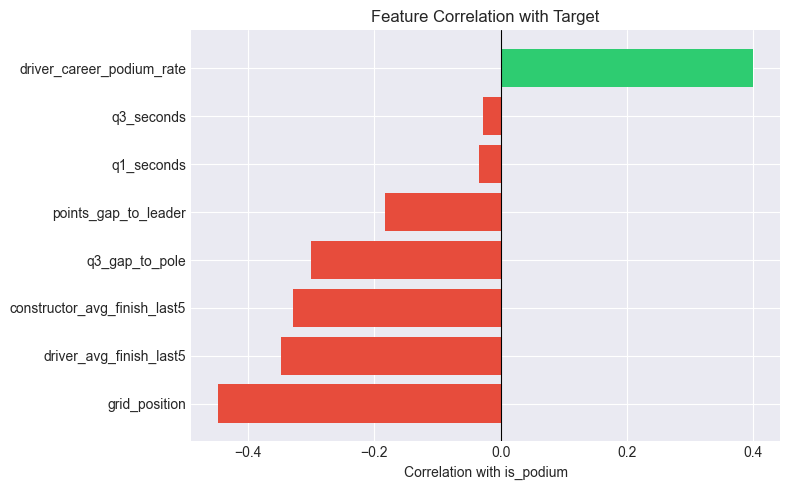

grid_position                  -0.447369
driver_avg_finish_last5        -0.347370
constructor_avg_finish_last5   -0.328266
q3_gap_to_pole                 -0.299675
points_gap_to_leader           -0.183243
q1_seconds                     -0.033460
q3_seconds                     -0.027780
driver_career_podium_rate       0.399701
Name: is_podium, dtype: float64


In [6]:
correlations = (
    df_feat[FEATURE_COLUMNS + [TARGET_COLUMN]]
    .corr()[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlation with is_podium")
ax.set_title("Feature Correlation with Target")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_correlations.png", dpi=150)
plt.show()

print(correlations)

## Podium vs non-podium: grid position

Quick sanity check — does grid position look different for podium finishers?

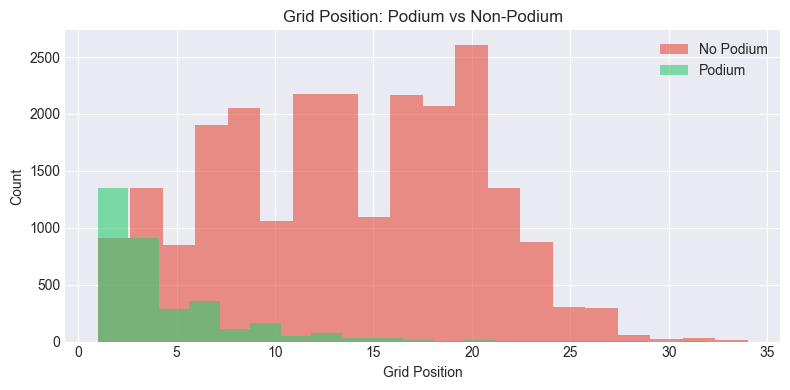

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
df_feat[df_feat[TARGET_COLUMN] == 0]["grid_position"].hist(
    bins=20, alpha=0.6, label="No Podium", color="#e74c3c", ax=ax
)
df_feat[df_feat[TARGET_COLUMN] == 1]["grid_position"].hist(
    bins=20, alpha=0.6, label="Podium", color="#2ecc71", ax=ax
)
ax.set_xlabel("Grid Position")
ax.set_ylabel("Count")
ax.set_title("Grid Position: Podium vs Non-Podium")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "grid_position_by_class.png", dpi=150)
plt.show()

## Save feature matrix

In [8]:
out_path = PROCESSED_DIR / "features_df.csv"
df_feat.to_csv(out_path, index=False)
print(f"Saved: {out_path}  ({df_feat.shape[0]} rows, {df_feat.shape[1]} cols)")
print(f"Feature columns: {FEATURE_COLUMNS}")
print(f"Target: {TARGET_COLUMN}")

Saved: C:\Users\Agam Katiyar\Projects\f1-ml-predictions\data\processed\features_df.csv  (26759 rows, 36 cols)
Feature columns: ['grid_position', 'q3_seconds', 'q3_gap_to_pole', 'q1_seconds', 'driver_avg_finish_last5', 'constructor_avg_finish_last5', 'driver_career_podium_rate', 'points_gap_to_leader']
Target: is_podium
